# Introduction

In this project, we analyze a customer shopping behavior dataset to understand purchasing patterns. 

We apply **Decision Tree models** to explore how different factors influence customer behavior.

## Decision Tree Model 1: Predicting Subscription Status

This model predicts whether a customer has a **subscription** based on their shopping behavior and demographic features.

The goal is to understand which factors influence customers to subscribe to a service.

Subscription Prediction Accuracy: 0.8269230769230769


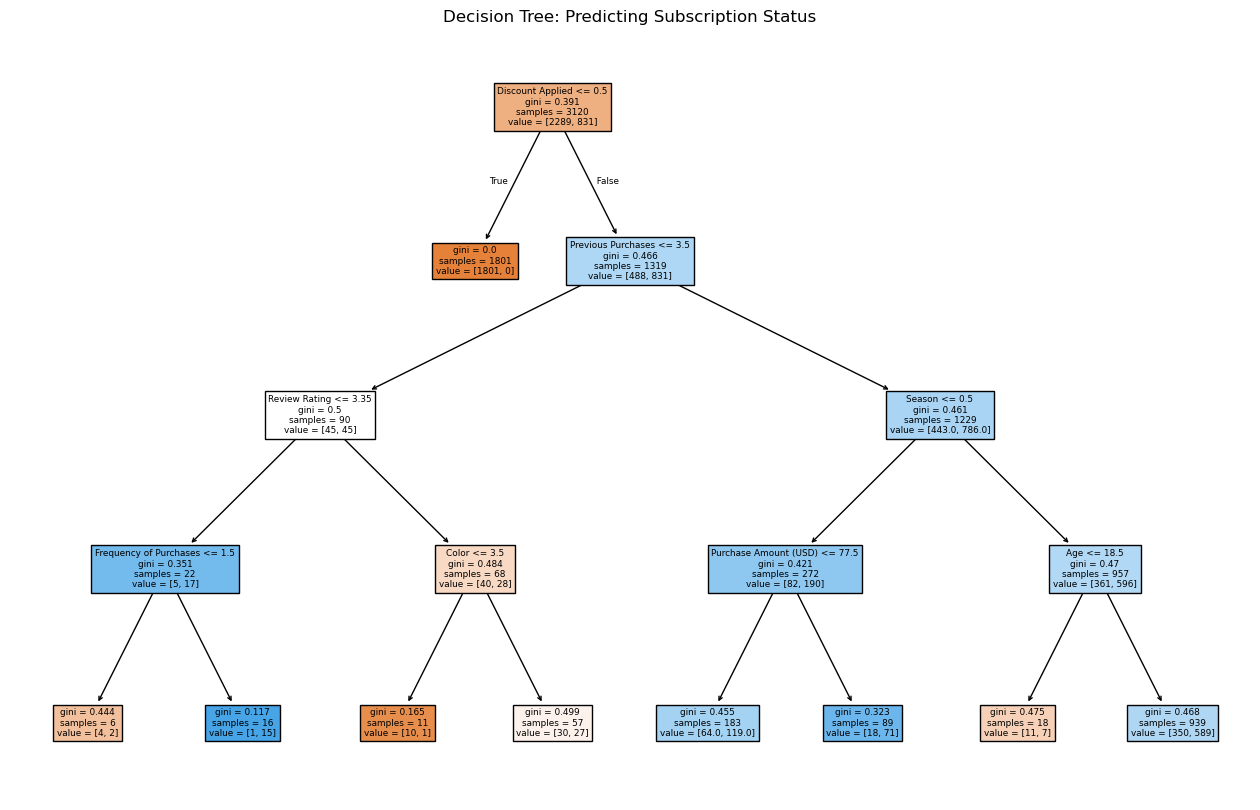

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("shopping_behavior_updated.csv")

# Drop ID column
df = df.drop("Customer ID", axis=1)

# Encode categorical variables
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

# Features and target
X = df.drop("Subscription Status", axis=1)
y = df["Subscription Status"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model1 = DecisionTreeClassifier(max_depth=4)
model1.fit(X_train, y_train)

# Prediction
pred1 = model1.predict(X_test)

print("Subscription Prediction Accuracy:", accuracy_score(y_test, pred1))

# Visualization
plt.figure(figsize=(16,10))
plot_tree(model1, feature_names=X.columns, filled=True)
plt.title("Decision Tree: Predicting Subscription Status")
plt.show()

## Decision Tree Model 2: Predicting Product Category

In this model, we predict the **product category** that a customer is likely to purchase.

This helps identify patterns between customer characteristics and the type of products they prefer.

Category Prediction Accuracy: 0.8294871794871795


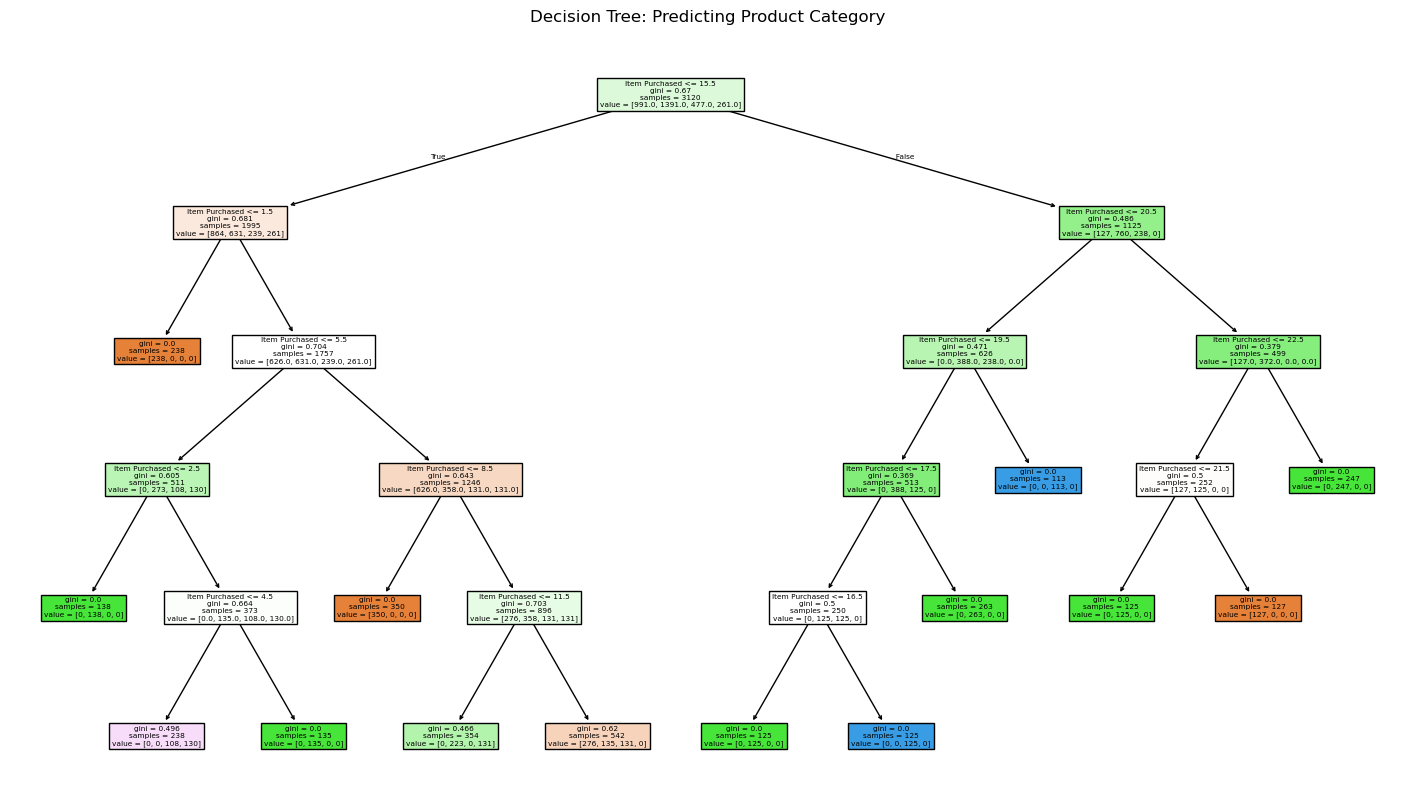

In [3]:
# Reload dataset
df = pd.read_csv("shopping_behavior_updated.csv")

df = df.drop("Customer ID", axis=1)

encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

# Features and target
X = df.drop("Category", axis=1)
y = df["Category"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model2 = DecisionTreeClassifier(max_depth=5)
model2.fit(X_train, y_train)

# Prediction
pred2 = model2.predict(X_test)

print("Category Prediction Accuracy:", accuracy_score(y_test, pred2))

# Visualization
plt.figure(figsize=(18,10))
plot_tree(model2, feature_names=X.columns, filled=True)
plt.title("Decision Tree: Predicting Product Category")
plt.show()

## Decision Tree Model 3: Predicting Spending Level
In this model, we classify **customers as Big Spenders or Small Spenders** based on their purchase amount.

This helps identify factors that distinguish high-value customers from low-value customers.

Spending Level Prediction Accuracy: 0.5051282051282051
Classification: 0 = Small Spender (≤ $60.00), 1 = Big Spender (> $60.00)


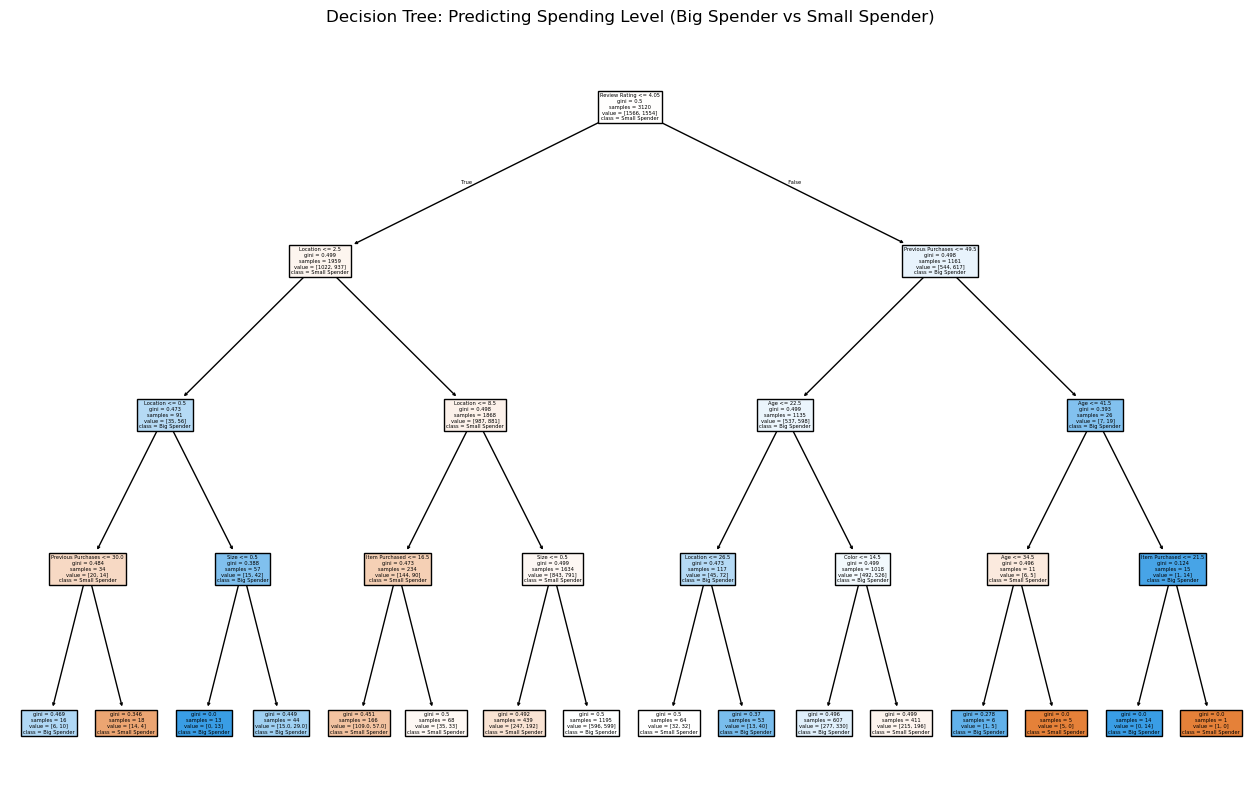

In [6]:
# Load dataset
df = pd.read_csv("shopping_behavior_updated.csv")

# Create spending category based on median purchase amount
median_spending = df["Purchase Amount (USD)"].median()
df["Spending Level"] = (df["Purchase Amount (USD)"] > median_spending).astype(int)

# Drop unnecessary columns
df = df.drop(["Customer ID", "Purchase Amount (USD)"], axis=1)

# Encode categorical variables
encoder = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object" and col != "Spending Level":
        df[col] = encoder.fit_transform(df[col])

# Features and target
X = df.drop("Spending Level", axis=1)
y = df["Spending Level"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model3 = DecisionTreeClassifier(max_depth=4)
model3.fit(X_train, y_train)

# Prediction
pred3 = model3.predict(X_test)

print("Spending Level Prediction Accuracy:", accuracy_score(y_test, pred3))
print(f"Classification: 0 = Small Spender (≤ ${median_spending:.2f}), 1 = Big Spender (> ${median_spending:.2f})")

# Visualization
plt.figure(figsize=(16,10))
plot_tree(model3, feature_names=X.columns, 
          class_names=['Small Spender', 'Big Spender'], 
          filled=True)
plt.title("Decision Tree: Predicting Spending Level (Big Spender vs Small Spender)")
plt.show()